In [1]:
import hotspot
import scanpy as sc
import numpy as np
import h5py
import os
import pandas as pd
from scipy.sparse import csc_matrix



/home/andi/.local/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
path = "/mnt/d/Starlng_paper/data/sergio_raw_5_tfs_seurat.h5ad"

In [32]:
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 1200 × 236
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gt_clusters'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank', 'highly_variable'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [34]:
adata.obs["total_counts"] = adata.X.sum(axis=1)
adata

AnnData object with n_obs × n_vars = 1200 × 236
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'gt_clusters', 'total_counts'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank', 'highly_variable'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [33]:
adata.X

<1200x236 sparse matrix of type '<class 'numpy.float64'>'
	with 98287 stored elements in Compressed Sparse Row format>

In [35]:
adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes = 5)
sc.pp.filter_genes(adata, min_cells = 5)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [36]:
adata.layers["log_normalized"] = adata.layers["counts"]
sc.pp.scale(adata)

/usr/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [37]:
adata.X

array([[ 1.25381579, -0.36776812,  0.94716537, ..., -1.51532115,
        -1.21592467,  0.74204471],
       [ 1.08294813, -0.36776812, -0.94788205, ..., -1.51532115,
        -1.21592467, -1.25163071],
       [ 1.30675434, -0.36776812, -0.94788205, ...,  0.313716  ,
        -1.21592467, -1.25163071],
       ...,
       [-0.88975565, -0.36776812, -0.94788205, ...,  1.09742193,
        -1.21592467, -1.25163071],
       [ 1.32094745, -0.36776812,  1.2384828 , ...,  0.78934488,
         0.87387721,  0.74349842],
       [-0.88975565, -0.36776812,  0.98267934, ...,  0.65990934,
         0.75699309,  0.71154763]])

In [ ]:
sc.pp.pca(adata, mask_var = None)

In [41]:
adata.layers["counts"] = adata.layers["counts"].todense()

/home/andi/.local/lib/python3.10/site-packages/anndata/_core/storage.py:39: ImplicitModificationWarning: Layer 'counts' should not be a np.matrix, use np.ndarray instead.
  warnings.warn(msg, ImplicitModificationWarning)


In [ ]:
hs = hotspot.Hotspot(
    adata,
    layer_key = "counts",
    model = "danb",
    latent_obsm_key = "X_pca",
    umi_counts_obs_key = "total_counts"
)


In [43]:
np.random.seed(42)
hs.create_knn_graph(weighted_graph = False, n_neighbors = 30)
hs_results = hs.compute_autocorrelations(jobs = 4)

100%|██████████| 236/236 [00:01<00:00, 162.08it/s]


In [44]:
hs_genes = hs_results.loc[hs_results.FDR < 0.05].sort_values('Z', ascending=False)
print(f"Number of genes with FDR < 0.05: {hs_genes.shape[0]}")
hs_genes = hs_genes.index

Number of genes with FDR < 0.05: 236


In [45]:
lcz = hs.compute_local_correlations(hs_genes, jobs = 30)

modules = hs.create_modules(
    min_gene_threshold = 20,
    fdr_threshold = 0.05,
    core_only = True
)

Computing pair-wise local correlation on 236 features...


100%|██████████| 27730/27730 [00:05<00:00, 4915.38it/s] 


In [47]:
modules

ATF6       1
AIFM1      1
AGBL3      1
FBXO8      1
GABPA      3
          ..
ANTXR2    -1
EDEM2      2
GABPB1     4
METTL17   -1
PRKAR1A   -1
Name: Module, Length: 236, dtype: int64

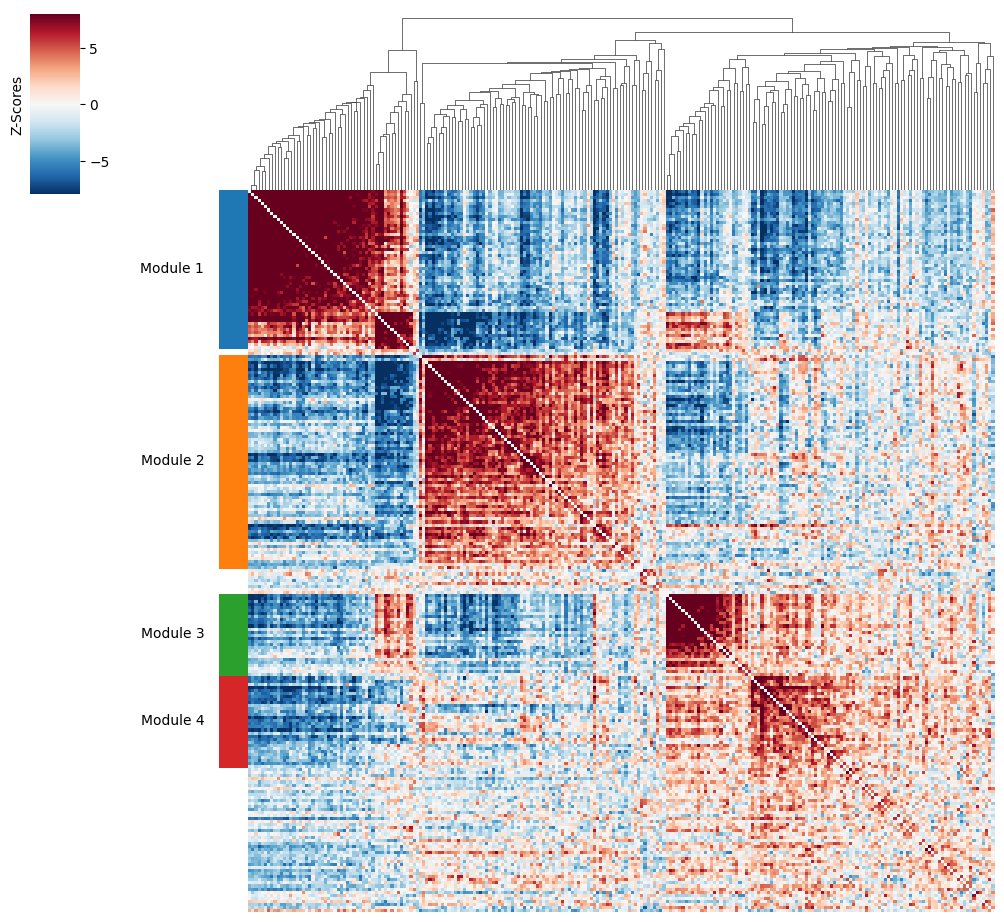

In [46]:
hs.plot_local_correlations()